# 00 배경 — 카드 밖 지표로 본 인천: 상권 침체였는가

본분석(`02_main_DDD.ipynb`)은 대형할인점을 기준선으로 **카드 데이터 안에서** 대체효과를 논증한다.
이 노트북은 그 논증을 **카드 밖 지표**로 검증한다.

**핵심 논리**

```
서비스업동향조사 = 사업체의 매출액 조사 → 결제수단을 가리지 않음 (지역화폐 결제도 매출로 잡힘)
BC카드 데이터    = 카드 결제만 관측
두 지표의 괴리   = 결제수단 이동
```

실물 지표에서 인천이 정상인데 카드에서만 빠졌다면, 그 차이는 상권 침체가 아니라 결제수단 이동이다.

**자료** — 국가데이터처 「서비스업동향조사」, 행정안전부 주민등록인구 (KOSIS, 2026.09.19 다운로드)

## 0. 환경 설정

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import glob, os
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
OUT = Path("../outputs/00_background"); OUT.mkdir(parents=True, exist_ok=True)   # 그림 저장 폴더

mpl.rcParams["font.family"] = "Apple SD Gothic Neo"
mpl.rcParams["axes.unicode_minus"] = False           # 유니코드 마이너스는 한글 폰트에서 깨진다
mpl.rcParams["figure.dpi"] = 110

DATA = "../data"

TREAT = "인천광역시"
EXCL_SIDO = ["서울특별시", "부산광역시", "울산광역시"]   # POST 기간 지역화폐 변동 — 02 본분석과 동일 배제

Q_PRE  = ["2025.1/4", "2025.2/4", "2025.3/4", "2025.4/4", "2026.1/4"]
Q_POST = "2026.2/4"                                      # 5·6월 포함 분기 (4월 혼입 → 효과 1/3 희석)

pd.set_option("display.max_columns", 50); pd.set_option("display.width", 160)

def find(pat):
    return glob.glob(os.path.join(DATA, pat))[0]

## 1. 데이터 로드 — KOSIS 3종

KOSIS 엑셀은 헤더가 다층이고 지역명이 병합 셀이라 그대로 읽히지 않는다. 세 파일 모두 long 형태로 정규화한다.

In [2]:
SIDO_FIX = {"세종시": "세종특별자치시"}                  # 파일 간 시도명 표기 차이

def load_retail():
    """시도별 소매판매액지수 — 헤더 1줄, 분기 6열"""
    r = pd.read_excel(find("시도별_소매판매액지수*.xlsx"), header=None)
    cols = r.iloc[0].tolist(); r = r.iloc[1:].copy(); r.columns = cols
    r["행정구역별"] = r["행정구역별"].ffill()
    qs = [c for c in cols if "/4" in str(c)]
    return r.melt(id_vars=["행정구역별", "업종별"], value_vars=qs, var_name="q", value_name="idx")

def load_svc():
    """시도별 서비스업생산지수 — 헤더 2줄(분기 × 경상/불변). 카드 금액이 명목이므로 경상지수 사용"""
    s = pd.read_excel(find("시도별_서비스업생산지수*.xlsx"), header=None)
    h0, h1 = s.iloc[0].ffill().tolist(), s.iloc[1].tolist()
    s = s.iloc[2:].copy(); s.columns = [f"{a}|{b}" for a, b in zip(h0, h1)]
    s = s.rename(columns={"행정구역별|행정구역별": "행정구역별", "업종별|업종별": "업종별"})
    s["행정구역별"] = s["행정구역별"].ffill()
    sc = [c for c in s.columns if "|경상지수" in c]
    d = s.melt(id_vars=["행정구역별", "업종별"], value_vars=sc, var_name="q", value_name="idx")
    d["q"] = d["q"].str.split("|").str[0]
    return d

retail, svc = load_retail(), load_svc()
for d in (retail, svc):
    d["q"]   = d["q"].astype(str).str.replace(" p)", "", regex=False).str.strip()   # 2026.2/4는 잠정치
    d["idx"] = pd.to_numeric(d["idx"], errors="coerce")
    d["시도"] = d["행정구역별"].replace(SIDO_FIX)

print("소매판매액지수 ", retail.shape, sorted(retail["업종별"].unique()))
print("서비스업생산지수", svc.shape, "| 시도", svc["시도"].nunique(), "| 분기", sorted(svc["q"].unique()))

소매판매액지수  (588, 5) ['대형마트', '면세점', '백화점', '슈퍼마켓· 잡화점 및 편의점', '승용차 및 연료소매점', '전문소매점', '총지수']
서비스업생산지수 (1428, 5) | 시도 17 | 분기 ['2025.1/4', '2025.2/4', '2025.3/4', '2025.4/4', '2026.1/4', '2026.2/4']


### 인사이트 · 자료 구조

`소매판매액지수`에 **대형마트**와 **슈퍼마켓·잡화점 및 편의점**이 분리되어 있다.
본분석의 C(대형할인점) / T(편의점·슈퍼마켓) 구분과 직접 대응한다. 외부 지표로 같은 구조의 위약검정이 가능하다.

`(확인 필요)` 소매판매액지수의 경상/불변 여부가 메타정보에 명시되지 않음. 통계청 관례상 불변지수로 추정.
서비스업생산지수는 경상·불변이 모두 제공되어 **경상지수**를 쓴다 — 카드 금액이 명목이므로.

## 2. 업태 대응

| 카드 데이터 (11개 식음료 업종) | 외부 지표 | 카드 Δ (대조군 A 기준) |
|---|---|---|
| 대형할인점 — **C, 캐시백 비대상** | 소매판매 › 대형마트 | −1.6 |
| 편의점 · 슈퍼마켓 — T | 소매판매 › 슈퍼마켓·잡화점 및 편의점 | −7.9 / −4.9 |
| 일반한식 · 중국음식 · 일식회집 · 서양음식 · 스넥 — T | 서비스업생산 › 숙박 및 음식점업 | −8.4 ~ −11.8 |
| 제과점 — T | (소매·음식점 경계, 대응 없음) | −14.1 |

**소매판매액지수 총지수는 쓰지 않는다.** 승용차·연료·전문소매점 등 카드 분석에 없는 업태가 섞여 있다.

## 3. 인천 인구 — 소비 감소가 인구 유출 때문인가

"인구가 빠져서 소비가 줄었다"는 반론을 먼저 차단한다.

In [3]:
p = pd.read_excel(find("행정구역_시군구_별__성별_인구수*.xlsx"), header=None)
h0, h1 = p.iloc[0].ffill(), p.iloc[1]
pop = p.iloc[2:].copy(); pop.columns = [f"{a}|{b}" for a, b in zip(h0, h1)]
pop = pop.rename(columns={pop.columns[0]: "지역"})
pop["지역"] = pop["지역"].astype(str).str.replace("\u3000", "", regex=False).str.strip()
tot = [c for c in pop.columns if "총인구수" in str(c)]

ic = pop.loc[pop["지역"] == TREAT, tot].astype(float).iloc[0]
ic.index = [c.split("|")[0] for c in tot]
print(ic.astype(int).to_string())
print("\n2026.01 → 06 변화: %+.2f%%" % ((ic.iloc[-1] / ic.iloc[0] - 1) * 100))

2026.01    3053308
2026.02    3054367
2026.03    3055983
2026.04    3057226
2026.05    3058623
2026.06    3061002

2026.01 → 06 변화: +0.25%


### 인사이트 · 인구

인천 인구는 관측 기간 내내 **증가**했다 (+0.25%). 인구 유출로 소비 감소를 설명할 수 없다.
이 반론은 본문에서 한 줄로 기각한다.

## 4. 전년동분기비 DiD — 실물 지표에 인천 이탈이 있는가

분기 지수는 계절성이 강하므로 **전년동분기비**로 변환한 뒤 인천과 대조군을 비교한다.
대조군은 인천과 오염 시도 3곳(서울·부산·울산)을 뺀 13개 시도의 **중앙값** — 02 본분석의 배제 기준과 동일하다.

In [4]:
def yoy(d, item):
    x = d[d["업종별"] == item].pivot_table(index="시도", columns="q", values="idx")
    return pd.DataFrame({q26: (x[q26] / x[q25] - 1) * 100
                         for q26, q25 in [("2026.1/4", "2025.1/4"), ("2026.2/4", "2025.2/4")]})

def did(d, item, label):
    y   = yoy(d, item)
    ctl = y.drop(index=[i for i in [TREAT] + EXCL_SIDO if i in y.index])
    res = pd.DataFrame({"인천": y.loc[TREAT], "대조군 중앙값": ctl.median()})
    res["편차"] = res["인천"] - res["대조군 중앙값"]
    gap = res.loc[Q_POST, "편차"] - res.loc["2026.1/4", "편차"]
    DIDF[label] = res
    print(f"── {label} · {item}")
    print(res.round(2).to_string())
    print(f"   실물 DiD = {gap:+.2f}%p\n")
    return gap

DIDF = {}
gaps = {
    "C  대형마트":            did(retail, "대형마트", "소매 C"),
    "T  슈퍼마켓·편의점":     did(retail, "슈퍼마켓· 잡화점 및 편의점", "소매 T"),
    "T  숙박·음식점업":       did(svc,    "숙박 및 음식점업", "외식 T"),
}

── 소매 C · 대형마트
            인천  대조군 중앙값    편차
2026.1/4 -5.58   -10.07  4.49
2026.2/4 -7.85   -11.54  3.70
   실물 DiD = -0.79%p

── 소매 T · 슈퍼마켓· 잡화점 및 편의점
            인천  대조군 중앙값    편차
2026.1/4  1.48    -2.24  3.72
2026.2/4  4.34    -0.20  4.54
   실물 DiD = +0.82%p

── 외식 T · 숙박 및 음식점업
            인천  대조군 중앙값    편차
2026.1/4  1.18     2.35 -1.17
2026.2/4  2.36     4.14 -1.78
   실물 DiD = -0.61%p



### 인사이트 · 실물 DiD

세 업태 모두 실물 DiD가 **±1%p 이내**다. 카드 데이터의 −9%p 격차에 대응하는 실물 하락이 없다.

특히 슈퍼마켓·편의점은 인천이 2026년 2분기에 전년 대비 **+4.3%**로 대조군(−0.2%)보다 **높다**.
카드에서 −7.9 / −4.9로 빠진 바로 그 업태다. 매출은 늘었는데 카드 결제만 줄었다.

## 5. 상대지수 — 평상시 편차 폭 대비 2026년 2분기

DiD 값이 작다는 것만으로는 부족하다. 인천의 **평상시 변동 폭**을 알아야 2026년 2분기가 이탈인지 판단할 수 있다.
`인천 지수 ÷ 대조군 중앙값 × 100`을 6개 분기에 걸쳐 추적한다 — 같은 분기끼리 나누므로 계절성이 상쇄된다.

In [5]:
def rel(d, item, label):
    x   = d[d["업종별"] == item].pivot_table(index="시도", columns="q", values="idx")
    ctl = x.drop(index=[i for i in [TREAT] + EXCL_SIDO if i in x.index])
    s   = (x.loc[TREAT] / ctl.median() * 100).reindex(Q_PRE + [Q_POST])
    REL[label] = s
    mu, sd = s[Q_PRE].mean(), s[Q_PRE].std()
    z = (s[Q_POST] - mu) / sd
    print(f"── {label} · {item}")
    print("   " + "  ".join(f"{q[-8:]} {v:.1f}" for q, v in s.items()))
    print(f"   PRE 5분기 평균 {mu:.1f} · 표준편차 {sd:.2f} → 2026.2/4 {s[Q_POST]:.1f} (z = {z:+.2f})\n")
    return z

REL = {}
zs = {
    "C  대형마트":        rel(retail, "대형마트", "소매 C"),
    "T  슈퍼마켓·편의점": rel(retail, "슈퍼마켓· 잡화점 및 편의점", "소매 T"),
    "T  숙박·음식점업":   rel(svc,    "숙박 및 음식점업", "외식 T"),
}

── 소매 C · 대형마트
   2025.1/4 117.0  2025.2/4 116.9  2025.3/4 120.9  2025.4/4 122.0  2026.1/4 123.4  2026.2/4 120.2
   PRE 5분기 평균 120.0 · 표준편차 2.97 → 2026.2/4 120.2 (z = +0.06)

── 소매 T · 슈퍼마켓· 잡화점 및 편의점
   2025.1/4 94.3  2025.2/4 97.4  2025.3/4 97.3  2025.4/4 97.3  2026.1/4 96.9  2026.2/4 97.4
   PRE 5분기 평균 96.6 · 표준편차 1.31 → 2026.2/4 97.4 (z = +0.56)

── 외식 T · 숙박 및 음식점업
   2025.1/4 90.2  2025.2/4 89.1  2025.3/4 88.0  2025.4/4 89.4  2026.1/4 89.7  2026.2/4 88.1
   PRE 5분기 평균 89.3 · 표준편차 0.83 → 2026.2/4 88.1 (z = -1.43)



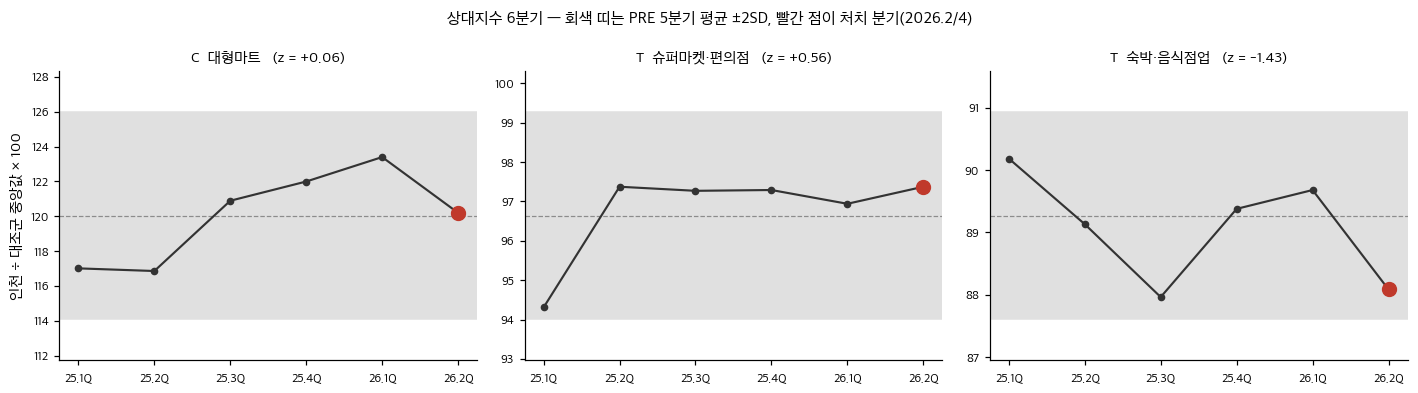

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True)

for ax, ser, (label, z) in zip(axes, REL.values(), zs.items()):
    mu, sd = ser[Q_PRE].mean(), ser[Q_PRE].std()
    x = range(len(ser))
    ax.axhspan(mu - 2 * sd, mu + 2 * sd, color="0.88", zorder=0)        # 평상시 변동 범위 ±2SD
    ax.axhline(mu, color="0.55", lw=0.8, ls="--", zorder=1)
    ax.plot(x, ser.values, "-o", color="#333", ms=4, lw=1.4, zorder=2)
    ax.plot(len(ser) - 1, ser.iloc[-1], "o", color="#c0392b", ms=9, zorder=3)  # 처치 분기
    ax.set_title(f"{label}   (z = {z:+.2f})", fontsize=10)
    ax.set_ylim(min(mu - 2.8 * sd, ser.min() - 0.4 * sd), max(mu + 2.8 * sd, ser.max() + 0.4 * sd))
    ax.set_xticks(list(x)); ax.set_xticklabels([q.replace("20", "").replace("/4", "Q") for q in ser.index], fontsize=8)
    ax.tick_params(labelsize=8)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)

axes[0].set_ylabel("인천 ÷ 대조군 중앙값 × 100")
fig.suptitle("상대지수 6분기 — 회색 띠는 PRE 5분기 평균 ±2SD, 빨간 점이 처치 분기(2026.2/4)", fontsize=10.5)
fig.tight_layout(); plt.savefig(OUT / "05_relative_index.png", dpi=200, bbox_inches="tight"); plt.show()

### 인사이트 · 상대지수

인천의 상대 위치는 6개 분기 내내 평탄하다. 2026년 2분기 z값은 +0.06 / +0.56 / −1.43으로
모두 평상시 변동 범위 안이다. **실물 지표에서 인천의 이탈은 관측되지 않는다.**

숙박·음식점업의 z = −1.43이 셋 중 가장 크지만, 상대지수 자체의 하락폭은 −1.2%p에 그친다.
같은 업종의 카드 Δ가 −8.4 ~ −11.8인 것과 한 자릿수 이상 차이 난다.

## 6. 카드 vs 실물 대조

두 지표를 나란히 놓는다. 이 표가 이 노트북의 결론이다.

In [7]:
CARD_DID = {"C  대형마트": -1.6, "T  슈퍼마켓·편의점": -6.4, "T  숙박·음식점업": -10.1}
# 카드 Δ: 대조군 A 기준. T 소매 = 편의점(-7.9)·슈퍼마켓(-4.9) 평균, T 외식 = 5개 업종 평균

cmp = pd.DataFrame({
    "카드 Δ (%p)":   pd.Series(CARD_DID),
    "실물 DiD (%p)": pd.Series(gaps).round(2),
    "상대지수 z":     pd.Series(zs).round(2),
})
cmp["괴리 (%p)"] = (cmp["카드 Δ (%p)"] - cmp["실물 DiD (%p)"]).round(2)
print(cmp.to_string())

             카드 Δ (%p)  실물 DiD (%p)  상대지수 z  괴리 (%p)
C  대형마트           -1.6        -0.79    0.06    -0.81
T  슈퍼마켓·편의점       -6.4         0.82    0.56    -7.22
T  숙박·음식점업       -10.1        -0.61   -1.43    -9.49


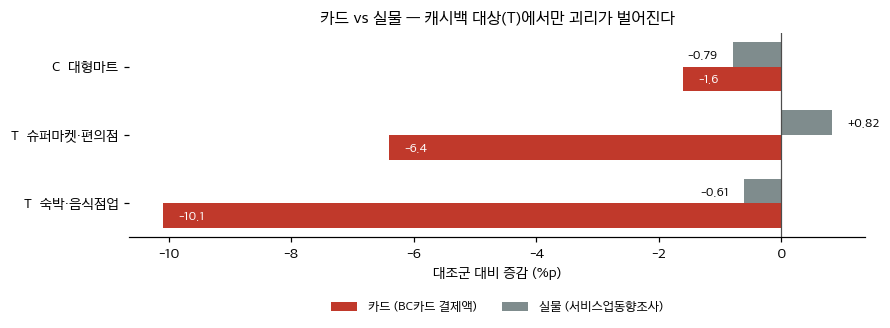

In [8]:
fig, ax = plt.subplots(figsize=(8.2, 3.4))

items = list(cmp.index)
y = np.arange(len(items)); h = 0.36
card = cmp["카드 Δ (%p)"].values
real = cmp["실물 DiD (%p)"].values

ax.barh(y + h/2, card, h, label="카드 (BC카드 결제액)", color="#c0392b")
ax.barh(y - h/2, real, h, label="실물 (서비스업동향조사)", color="#7f8c8d")

for yi, v in zip(y + h/2, card): ax.text(v + 0.25, yi, f"{v:+.1f}", va="center", ha="left", fontsize=8.5, color="w")
for yi, v in zip(y - h/2, real): ax.text(v + (0.25 if v >= 0 else -0.25), yi, f"{v:+.2f}",
                                         va="center", ha="left" if v >= 0 else "right", fontsize=8.5)

ax.axvline(0, color="0.3", lw=0.8)
ax.set_yticks(y); ax.set_yticklabels(items, fontsize=9.5)
ax.invert_yaxis(); ax.set_xlabel("대조군 대비 증감 (%p)", fontsize=9.5)
ax.set_title("카드 vs 실물 — 캐시백 대상(T)에서만 괴리가 벌어진다", fontsize=11)
ax.legend(fontsize=8.5, loc="lower center", bbox_to_anchor=(0.5, -0.42), ncol=2, frameon=False)
for sp in ("top", "right", "left"): ax.spines[sp].set_visible(False)
fig.tight_layout(); plt.savefig(OUT / "06_card_vs_real.png", dpi=200, bbox_inches="tight"); plt.show()

### 인사이트 · 대조

**C(대형할인점)에서는 카드와 실물이 일치한다.** 둘 다 −1%p 안팎으로, 캐시백 비대상 업종에서는 괴리가 없다.

**T(캐시백 대상)에서만 괴리가 벌어진다.** 실물은 0에 붙어 있는데 카드만 −6 ~ −10%p 빠졌다.
괴리가 캐시백 대상 여부를 따라 갈린다 — 침체라면 C에서도 똑같이 나타났어야 한다.

이것이 결제수단 이동의 직접 증거다. 본분석의 β₄ ≈ 0(업종 위약검정 통과)을 카드 밖 자료로 재확인한 것이기도 하다.

## 7. 요약 · 한계

**결론** — 2026년 2분기 인천의 실물 소비는 정상이었다. 카드 결제만 빠졌다.

| 업태 | 카드 Δ | 실물 DiD | 해석 |
|---|---|---|---|
| 대형할인점 (캐시백 비대상) | −1.6 | −0.79 | 일치 — 괴리 없음 |
| 슈퍼마켓·편의점 (대상) | −6.4 | +0.82 | 실물은 오히려 증가 |
| 숙박·음식점업 (대상) | −10.1 | −0.61 | 괴리 약 9.5%p |

인구도 관측 기간 내내 증가했으므로 인구 유출 설명도 성립하지 않는다.

**한계**

1. **분기 단위** — 2026년 2분기에 4월(처치 전)이 섞여 효과가 약 1/3 희석된다.
   희석은 "차이 없음"을 쉽게 만드는 방향이므로 §4·5의 결론은 이 한계에 취약하다.
   다만 카드 격차(−9%p)의 2/3인 −6%p 수준은 나타났어야 하는데 관측값은 ±1%p다 — 희석으로 설명되지 않는 크기다.
2. **시도 단위** — 강화·옹진이 포함되어 본분석의 도시 8개 구와 범위가 다르다. 두 지역 비중이 작아 방향은 유지될 것으로 본다.
3. **업종 범위 불일치** — 숙박업이 음식점업에 묶여 있고, 제과점은 대응 지표가 없다.
4. **표본조사 기반** — 서비스업동향조사는 표본조사이며 시도 단위 지수의 표준오차는 공표되지 않는다.
   §5의 상대지수 표준편차(PRE 5분기)가 사실상 그 대용이다.
5. **2026.2/4는 잠정치(p)** — 확정치에서 소폭 개정될 수 있다.

**본문 배치** — §2 배경의 마지막 절. 본분석의 평행추세·DDD보다 **앞에** 놓는다.
"우리 데이터로 보니 빠졌다"가 아니라 "실물은 멀쩡한데 카드만 빠졌다"로 문제를 세우는 편이 강하다.